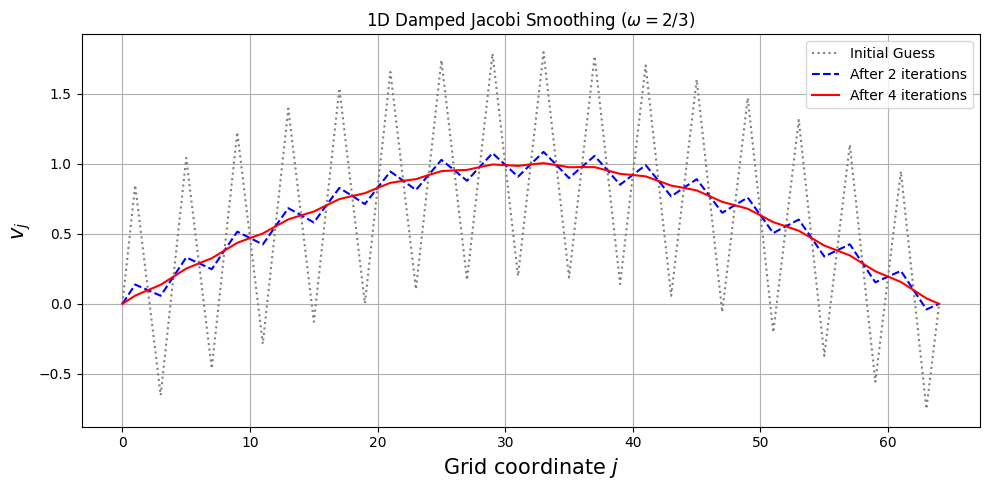

In [35]:
import torch
import matplotlib.pyplot as plt


def laplace_jacobi_1d_smoothen(v: torch.Tensor, omega: float = 2/3, iterations: int = 10) -> torch.Tensor:
    """
    Runs damped Jacobi for the 1D Laplace equation (Au = 0).
    Assumes homogeneous Dirichlet boundary conditions: v[0] = v[-1] = 0.

    Args:
        v: 1D torch.Tensor representing the initial guess.
        omega: The damping factor (default 2/3 for optimal high-frequency damping).
        iterations: Number of Jacobi steps to perform.
    """
    v_out = v.clone()

    for _ in range(iterations):
        # 1D Laplace Jacobi step: 0.5 * (left_neighbor + right_neighbor)
        v_jacobi = 0.5 * (v_out[:-2] + v_out[2:])

        # Damped update for the interior points
        v_out[1:-1] = (1 - omega) * v_out[1:-1] + omega * v_jacobi

    return v_out

# === Running the Simulation ===

# 1. Setup the grid (n=64 grid intervals)
n = 64
x = torch.linspace(0, n, n+1)

# 2. Specify the initial guess
v_initial = torch.zeros(n+1)

modes = [1, 32] # modes that are contained in the initial error
mode_proportions = [1, 0.8] # the contained proportion of the respective mode
for i in range(len(modes)):
    v_initial = v_initial + mode_proportions[i] * torch.sin(modes[i] * torch.pi * x / n)

# Enforce v_0 = v_n = 0
v_initial[0] = 0.0
v_initial[-1] = 0.0

# 3. Run specified number of iterations
first_iterations = 2
second_iterations = 2

v_first_smoothed = laplace_jacobi_1d_smoothen(v_initial, omega=2/3, iterations=first_iterations)
v_second_smoothed = laplace_jacobi_1d_smoothen(v_first_smoothed, omega=2/3, iterations=second_iterations)

# 4. Plot the results
plt.figure(figsize=(10, 5))
plt.plot(x.numpy(), v_initial.numpy(), label=f'Initial Guess', linestyle=':', color='gray')
plt.plot(x.numpy(), v_first_smoothed.numpy(), label=f'After {first_iterations} iterations', linestyle='--', color='blue')
plt.plot(x.numpy(), v_second_smoothed.numpy(), label=f'After {first_iterations + second_iterations} iterations', color='red')
plt.title(r'1D Damped Jacobi Smoothing ($\omega = 2/3$)')
plt.xlabel('Grid coordinate $j$', fontsize=15)
plt.ylabel('$v_j$', fontsize=15)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()